# 01 — Data Exploration

Exploratory analysis of the cleaned `laotse/credit-risk-dataset`, before any feature engineering (roadmap Phase 3). Reads `data/interim/credit_risk_validated.parquet`, the output of `scripts/ingest_data.py` — run that script first if this file doesn't exist yet, or if you've placed a newer copy of the raw CSV at `data/raw/credit_risk_dataset.csv`.

See `docs/data_dictionary.md` for column definitions, `docs/data_quality_report.md` for the full data quality report (including exactly which rows were excluded and why), and `SPECS.md §29` for the fields this exploration is expected to cover.


In [1]:
import matplotlib.pyplot as plt
import pandas as pd

# Reads the cleaned, schema-and-value-validated dataset that
# scripts/ingest_data.py produces (data/raw/credit_risk_dataset.csv minus
# rows excluded for impossible values, e.g. person_age of 123/144 — see
# docs/data_quality_report.md for exactly which rows and why), rather than
# the raw CSV directly, since this is the data Phase 3 will actually use.
VALIDATED_PATH = "../data/interim/credit_risk_validated.parquet"
TARGET = "loan_status"

df = pd.read_parquet(VALIDATED_PATH)
df.shape

(32574, 12)

## Overview

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32574 entries, 0 to 32573
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32574 non-null  int64  
 1   person_income               32574 non-null  int64  
 2   person_home_ownership       32574 non-null  str    
 3   person_emp_length           31679 non-null  float64
 4   loan_intent                 32574 non-null  str    
 5   loan_grade                  32574 non-null  str    
 6   loan_amnt                   32574 non-null  int64  
 7   loan_int_rate               29459 non-null  float64
 8   loan_status                 32574 non-null  int64  
 9   loan_percent_income         32574 non-null  float64
 10  cb_person_default_on_file   32574 non-null  str    
 11  cb_person_cred_hist_length  32574 non-null  int64  
dtypes: float64(3), int64(5), str(4)
memory usage: 3.5 MB


In [3]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
person_age,32574.0,NaN,NaN,NaN,27.718426,6.204987,20.0,23.0,26.0,30.0,94.0
person_income,32574.0,NaN,NaN,NaN,65878.480813,52531.938809,4000.0,38500.0,55000.0,79200.0,2039784.0
person_home_ownership,32574,4,RENT,16442,NaN,NaN,NaN,NaN,NaN,NaN,NaN
person_emp_length,31679.0,NaN,NaN,NaN,4.782064,4.034948,0.0,2.0,4.0,7.0,41.0
loan_intent,32574,6,EDUCATION,6451,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan_grade,32574,7,A,10776,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan_amnt,32574.0,NaN,NaN,NaN,9588.018051,6320.249598,500.0,5000.0,8000.0,12200.0,35000.0
loan_int_rate,29459.0,NaN,NaN,NaN,11.011529,3.240497,5.42,7.9,10.99,13.47,23.22
loan_status,32574.0,NaN,NaN,NaN,0.21818,0.413017,0.0,0.0,0.0,0.0,1.0
loan_percent_income,32574.0,NaN,NaN,NaN,0.170202,0.106755,0.0,0.09,0.15,0.23,0.83


## Missing values

In [4]:
missing = df.isna().mean().sort_values(ascending=False)
missing[missing > 0]

loan_int_rate        0.095628
person_emp_length    0.027476
dtype: float64

## Target distribution

How imbalanced is `loan_status`? This directly informs the class-balance handling decision in roadmap Phase 4 (`scale_pos_weight` / class weights / threshold tuning).

In [5]:
df[TARGET].value_counts(normalize=True)

loan_status
0    0.78182
1    0.21818
Name: proportion, dtype: float64

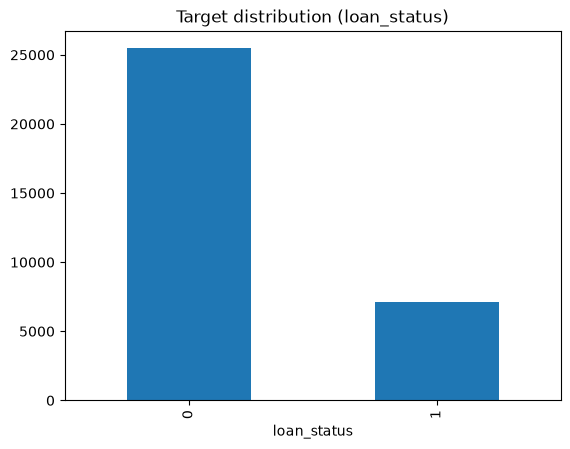

In [6]:
df[TARGET].value_counts().plot(kind="bar", title="Target distribution (loan_status)")
plt.show()

## Numeric feature distributions

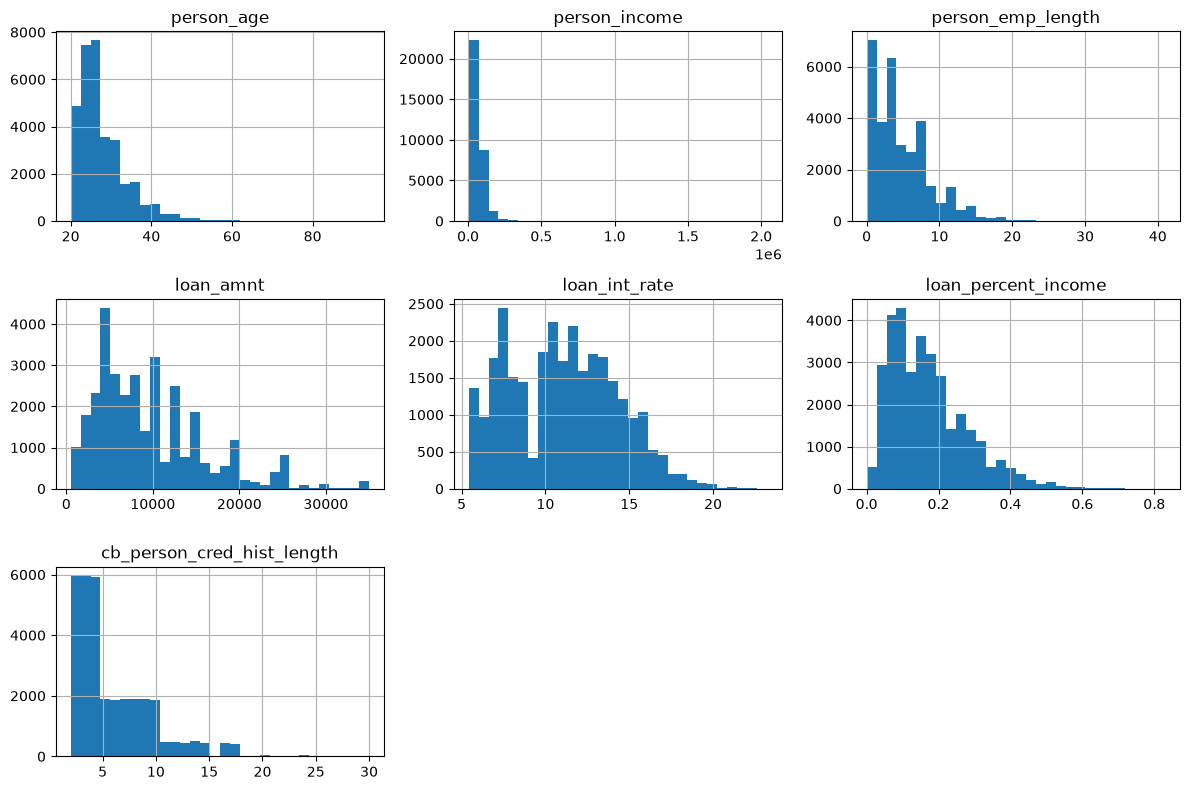

In [7]:
numeric_columns = df.select_dtypes("number").columns.drop(TARGET)
df[numeric_columns].hist(figsize=(12, 8), bins=30)
plt.tight_layout()
plt.show()

## Categorical feature distributions

In [8]:
categorical_columns = df.select_dtypes("object").columns
for column in categorical_columns:
    print(df[column].value_counts(normalize=True))
    print()

person_home_ownership
RENT        0.504758
MORTGAGE    0.412630
OWN         0.079327
OTHER       0.003285
Name: proportion, dtype: float64

loan_intent
EDUCATION            0.198041
MEDICAL              0.186376
VENTURE              0.175477
PERSONAL             0.169430
DEBTCONSOLIDATION    0.160005
HOMEIMPROVEMENT      0.110671
Name: proportion, dtype: float64

loan_grade
A    0.330816
B    0.320747
C    0.198195
D    0.111285
E    0.029594
F    0.007399
G    0.001965
Name: proportion, dtype: float64

cb_person_default_on_file
N    0.823663
Y    0.176337
Name: proportion, dtype: float64



/tmp/ipykernel_723/1720936339.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes("object").columns


## Default rate by categorical feature

Not just the marginal distribution — how the *default rate* varies within each category. This is the first look at which features are likely to matter, and a first pass at spotting any category that might function as a proxy for a protected characteristic (`docs/model_card.md`'s Bias considerations section, SPECS.md §37).

In [9]:
for column in categorical_columns:
    print(df.groupby(column)[TARGET].mean().sort_values(ascending=False))
    print()

person_home_ownership
RENT        0.315716
OTHER       0.308411
MORTGAGE    0.125735
OWN         0.074690
Name: loan_status, dtype: float64

loan_intent
DEBTCONSOLIDATION    0.285879
MEDICAL              0.267007
HOMEIMPROVEMENT      0.261026
PERSONAL             0.198768
EDUCATION            0.172221
VENTURE              0.148181
Name: loan_status, dtype: float64

loan_grade
G    0.984375
F    0.705394
E    0.644191
D    0.590345
C    0.207404
B    0.162806
A    0.099573
Name: loan_status, dtype: float64

cb_person_default_on_file
Y    0.377960
N    0.183973
Name: loan_status, dtype: float64



## Numeric feature correlation with target

In [10]:
df[[*numeric_columns.tolist(), TARGET]].corr()[TARGET].sort_values(ascending=False)

loan_status                   1.000000
loan_percent_income           0.379250
loan_int_rate                 0.335092
loan_amnt                     0.105240
cb_person_cred_hist_length   -0.015472
person_age                   -0.020687
person_emp_length            -0.085966
person_income                -0.168485
Name: loan_status, dtype: float64

## Notes for Phase 3 (historical EDA)

- Historical class prevalence is about 78.2% / 21.8%; compare weighting strategies on development data.
- Employment duration and interest rate require imputation fitted only on training rows.
- Grade has strong association with the target; that alone does not prove leakage or near-perfect prediction. It is excluded conservatively pending source timing/derivation evidence. Apply the same availability review to interest rate.
- The EDA used the full historical dataset. Do not describe the scoring holdout as completely unseen data.
- Baselines must keep identical raw model inputs together across splits. Saved outputs here precede that protocol and do not establish current model performance.
- Category default rates do not establish whether features proxy protected characteristics. Document the absence of a fairness audit.
